## Program Inversi Garis Regresi Linear
### Data
| i | Xi  | Yi  |
|---|-----|-----|
| 1 | 0.66 | 22.90 |
| 2 | 0.16 | 12.40 |
| 3 | 0.44 | 27.00 |
| 4 | 2.00 | 7.69 |
| 5 | 1.55 | 58.40 |
| 6 | 2.00 | 43.00 |
| 7 | 0.18 | 32.30 |
| 8 | 0.86 | 36.60 |

### Rumus
Model inversi dinyatakan sebagai:
$$ d = Gm $$

Solusi parameter model diperoleh dengan metode least squares:
$$ m = (G^T G)^{-1} G^T d $$

Dengan bentuk model linear:
$$ y = mx + c $$

### Langkah 1 : Masukkan Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Langkah 2 : Input dan Plot Data

In [2]:
# Input Data
Data = {
    'Nilai X': [
        0.66, 0.16, 0.44, 2.00, 1.55,
        2.00, 0.18, 0.86
    ],
    'Nilai Y': [
        22.90, 12.40, 27.00, 7.69, 58.40,
        43.00, 32.30, 36.60
    ]
}

Data_contoh = pd.DataFrame(Data)
Data_contoh

,Nilai X,Nilai Y
0,0.66,22.90
1,0.16,12.40
2,0.44,27.00
3,2.00,7.69
4,1.55,58.40
5,2.00,43.00
6,0.18,32.30
7,0.86,36.60


Text(0, 0.5, 'Nilai Y')

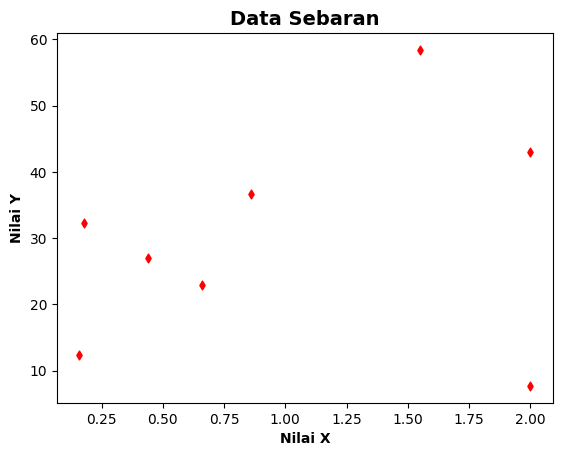

In [3]:
# Plot Data
Data_contoh.plot(kind = 'scatter', x = 'Nilai X', y = 'Nilai Y', c = 'red', marker = 'd')

plt.title('Data Sebaran', fontsize = 14, fontweight = 'bold')
plt.xlabel('Nilai X', fontsize = 10, fontweight = 'bold')
plt.ylabel('Nilai Y', fontsize = 10, fontweight = 'bold')

### Langkah 3 : Mengubah Data sebaran menjadi Array

In [4]:
x = np.array(Data_contoh['Nilai X']).reshape(-1,1)
y = np.array(Data_contoh['Nilai Y']).reshape(-1,1)

print(f'x = \n', x)
print(f'y = \n', y)

x = 
 [[0.66]
 [0.16]
 [0.44]
 [2.  ]
 [1.55]
 [2.  ]
 [0.18]
 [0.86]]
y = 
 [[22.9 ]
 [12.4 ]
 [27.  ]
 [ 7.69]
 [58.4 ]
 [43.  ]
 [32.3 ]
 [36.6 ]]


### Langkah 4 : Menghitung nilai d dan G

In [5]:
d = y.copy()
n_data = len(d)
n_par = 2

G = np.zeros((n_data,n_par))

for i in range(n_data):
    G[i,0] = x[i][0]
    G[i,1] = 1

print(f'd = \n', d)
print(f'G = \n', G)

d = 
 [[22.9 ]
 [12.4 ]
 [27.  ]
 [ 7.69]
 [58.4 ]
 [43.  ]
 [32.3 ]
 [36.6 ]]
G = 
 [[0.66 1.  ]
 [0.16 1.  ]
 [0.44 1.  ]
 [2.   1.  ]
 [1.55 1.  ]
 [2.   1.  ]
 [0.18 1.  ]
 [0.86 1.  ]]


### Langkah 5 : Solusi Inversi

Text(0.4, 7.8, 'y = 5.4243x + 24.71 \nError = 1769.890395')

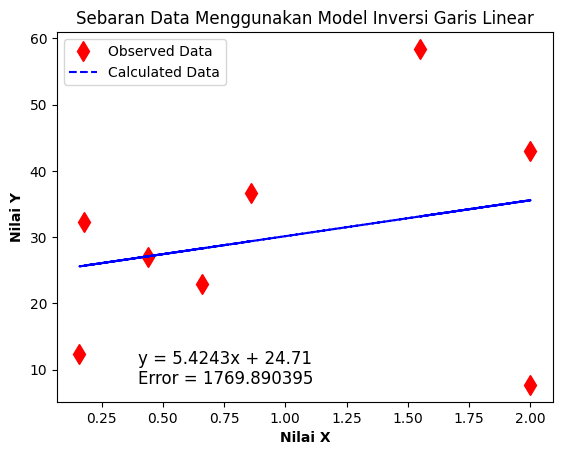

In [6]:
m, residuals, rank, s = np.linalg.lstsq(G,y)
slope = float (m[0][0])
intercept = float(m[1][0])
Err = float(residuals [0])

dcal = G@m

plt.title('Sebaran Data Menggunakan Model Inversi Garis Linear')
plt.plot(x,d, 'rd', markersize = 10, label = 'Observed Data')
plt.plot(x,dcal, 'b--', markersize = 8, label ='Calculated Data')
plt.xlabel('Nilai X', fontsize = 10, fontweight = 'bold')
plt.ylabel('Nilai Y', fontsize = 10, fontweight = 'bold')
plt.legend()

txt_str = (f'y = {slope:.4f}x + {intercept:.2f} \n'
            f'Error = {Err:.6f}')

plt.text(0.4, 7.8, txt_str, fontsize = 12)